<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 169.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 194.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 154.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 151.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 147.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


/tmp/ipykernel_298/3043340576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

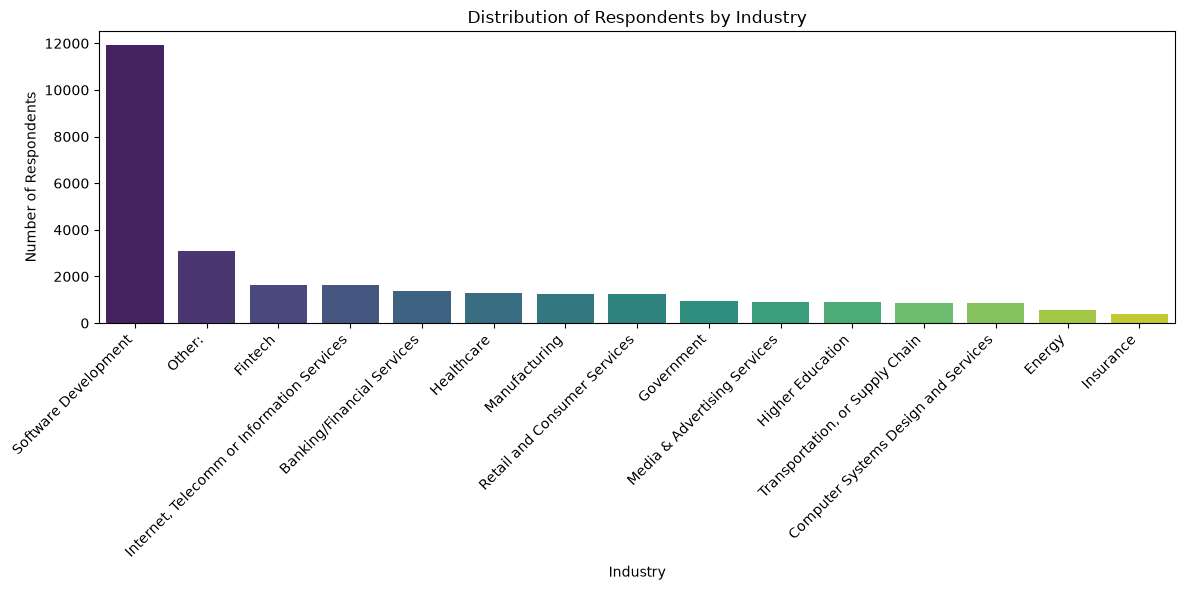

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64

In [3]:
# Count respondents per industry
industry_counts = df['Industry'].value_counts()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
x=industry_counts.index,
y=industry_counts.values,
palette='viridis'
)

plt.title('Distribution of Respondents by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display counts
print(industry_counts)

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
# Ensure column is numeric
df['ConvertedCompYearly'] = pd.to_numeric(
    df['ConvertedCompYearly'], errors='coerce'
)

# Basic statistics
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"Mean Compensation: {mean_comp:,.2f}")
print(f"Median Compensation: {median_comp:,.2f}")
print(f"Standard Deviation: {std_comp:,.2f}")

# Threshold: 3 standard deviations above the mean
threshold = mean_comp + 3 * std_comp

print(f"\nOutlier Threshold: {threshold:,.2f}")

# Respondents with extremely high compensation
high_comp = df[df['ConvertedCompYearly'] > threshold]

print(f"\nNumber of respondents above threshold: {len(high_comp)}")

# Display key information
cols_to_show = ['ResponseID', 'ConvertedCompYearly']

# Keep only columns that exist in the dataframe
cols_to_show = [col for col in cols_to_show if col in df.columns]

display(high_comp[cols_to_show].sort_values(
    by='ConvertedCompYearly',
    ascending=False
))

Mean Compensation: 86,155.29
Median Compensation: 65,000.00
Standard Deviation: 186,756.97

Outlier Threshold: 646,426.21

Number of respondents above threshold: 89

,ConvertedCompYearly
15837,16256603.0
12723,13818022.0
28379,9000000.0
17593,6340564.0
17672,4936778.0
...,...
13336,660660.0
6735,650000.0
529,650000.0
28381,650000.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [6]:
# Ensure the column is numeric
df['ConvertedCompYearly'] = pd.to_numeric(
df['ConvertedCompYearly'],
errors='coerce'
)

# Quartiles
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

# Outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:,.2f}")
print(f"Q3: {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")
print(f"Lower Bound: {lower_bound:,.2f}")
print(f"Upper Bound: {upper_bound:,.2f}")

Q1: 32,712.00
Q3: 107,971.50
IQR: 75,259.50
Lower Bound: -80,177.25
Upper Bound: 220,860.75

In [7]:
# Find outliers
outliers = df[
(df['ConvertedCompYearly'] < lower_bound) |
(df['ConvertedCompYearly'] > upper_bound)
]

print("Number of outliers:", len(outliers))

# Percentage of outliers
outlier_pct = (len(outliers) / len(df)) * 100
print(f"Percentage of outliers: {outlier_pct:.2f}%")

Number of outliers: 978
Percentage of outliers: 1.49%

In [8]:
cols = ['ResponseID', 'ConvertedCompYearly']

# Keep only existing columns
cols = [c for c in cols if c in df.columns]

outliers[cols].sort_values(
    by='ConvertedCompYearly',
    ascending=False
).head(20)

,ConvertedCompYearly
15837,16256603.0
12723,13818022.0
28379,9000000.0
17593,6340564.0
17672,4936778.0
19267,3367716.0
23694,2584118.0
33720,2237846.0
34523,2153432.0
13763,2048046.0


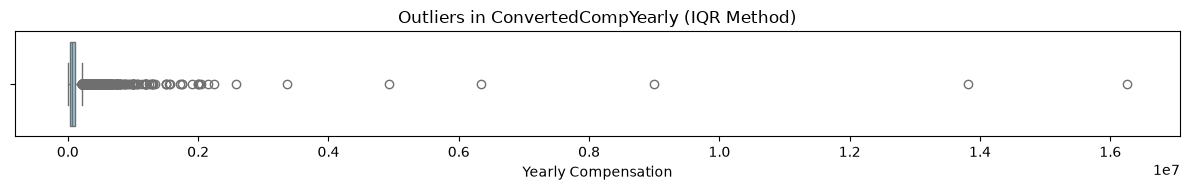

In [9]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    x=df['ConvertedCompYearly'],
    color='skyblue'
)

plt.title('Outliers in ConvertedCompYearly (IQR Method)')
plt.xlabel('Yearly Compensation')
plt.tight_layout()
plt.show()

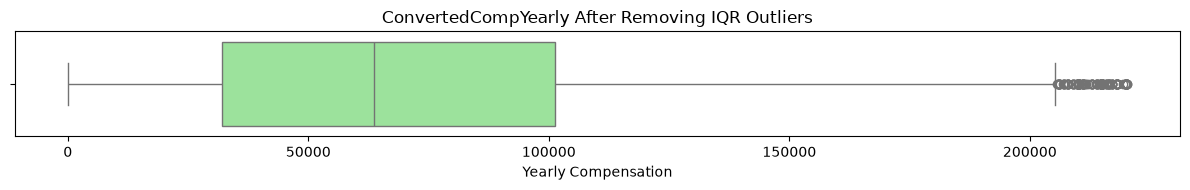

In [10]:
df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

plt.figure(figsize=(12, 2))
sns.boxplot(
    x=df_no_outliers['ConvertedCompYearly'],
    color='lightgreen'
)

plt.title('ConvertedCompYearly After Removing IQR Outliers')
plt.xlabel('Yearly Compensation')
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [12]:
# Create a new DataFrame without outliers
df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
].copy()

print("Original DataFrame shape:", df.shape)
print("New DataFrame shape:", df_no_outliers.shape)

print("\nRows removed:", len(df) - len(df_no_outliers))

Original DataFrame shape: (65437, 114)
New DataFrame shape: (22457, 114)

Rows removed: 42980

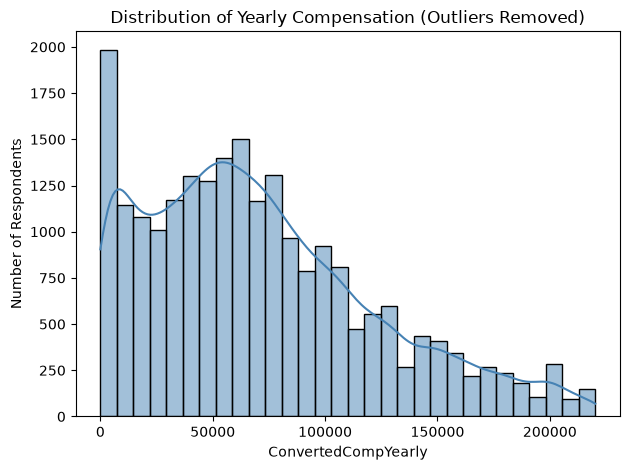

In [13]:
sns.histplot(
    data=df_no_outliers,
    x='ConvertedCompYearly',
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Yearly Compensation (Outliers Removed)')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [14]:
import numpy as np

# Map age ranges to approximate midpoints
age_map = {
'Under 18 years old': 17,
'18-24 years old': 21,
'25-34 years old': 29,
'35-44 years old': 39,
'45-54 years old': 49,
'55-64 years old': 59,
'65 years or older': 66
}

# Create numeric age column
df['AgeNumeric'] = df['Age'].map(age_map)

# Check mapping results
print(df[['Age', 'AgeNumeric']].head())

                  Age  AgeNumeric
0  Under 18 years old        17.0
1     35-44 years old        39.0
2     45-54 years old        49.0
3     18-24 years old        21.0
4     18-24 years old        21.0

In [15]:
# Ensure columns are numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Select variables
corr_cols = ['AgeNumeric', 'YearsCodePro', 'ConvertedCompYearly']

# Correlation matrix
corr_matrix = df[corr_cols].corr(method='pearson')

print(corr_matrix)

                     AgeNumeric  YearsCodePro  ConvertedCompYearly
AgeNumeric             1.000000      0.831083             0.121346
YearsCodePro           0.831083      1.000000             0.134353
ConvertedCompYearly    0.121346      0.134353             1.000000

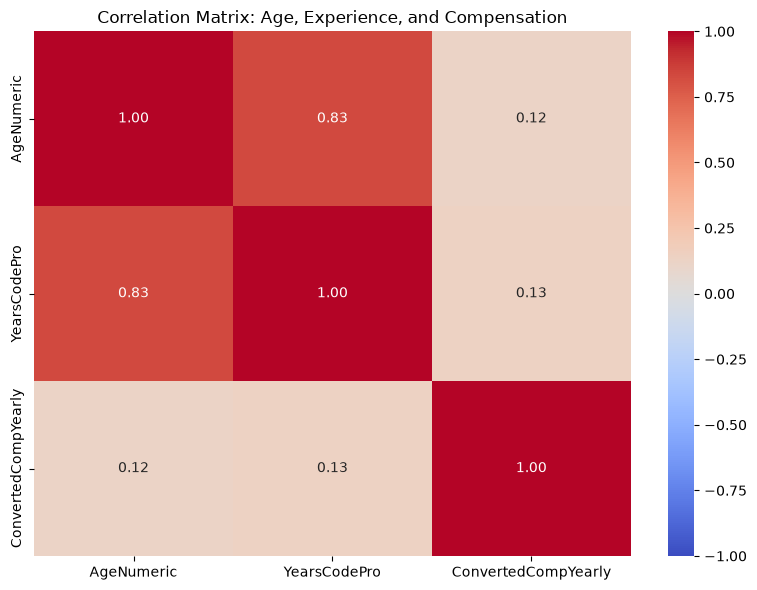

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix: Age, Experience, and Compensation')
plt.tight_layout()
plt.show()

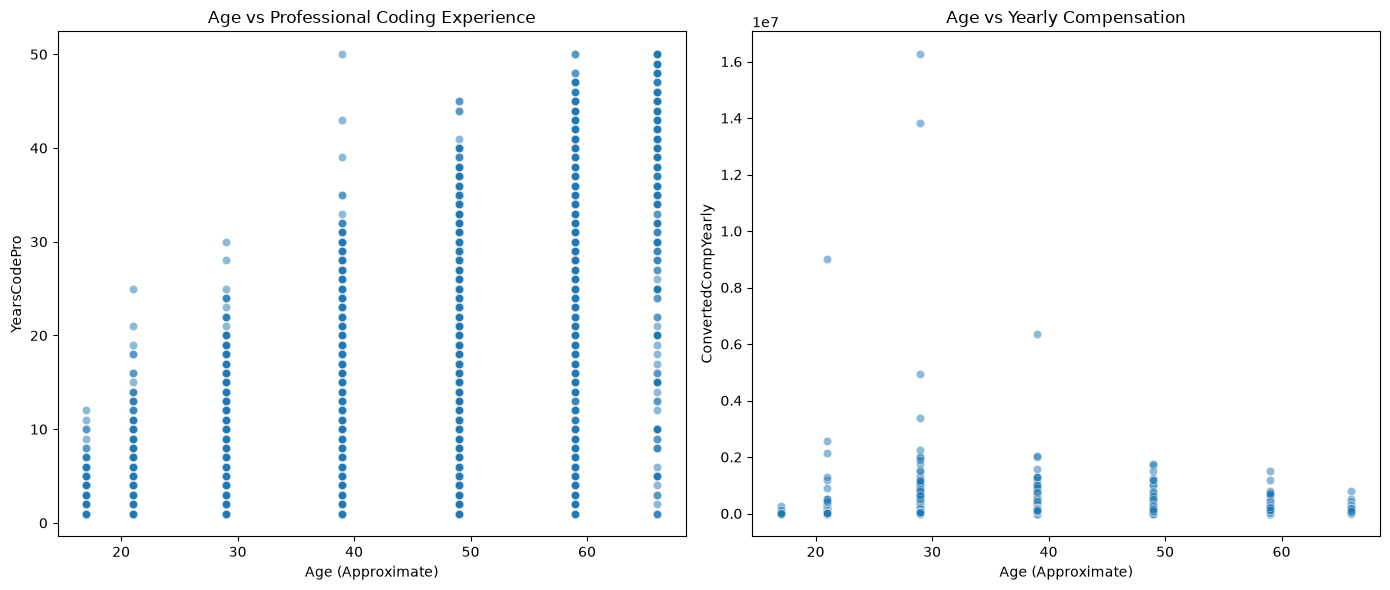

In [17]:
# Create side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age vs YearsCodePro
sns.scatterplot(
data=df,
x='AgeNumeric',
y='YearsCodePro',
alpha=0.5,
ax=axes[0]
)

axes[0].set_title('Age vs Professional Coding Experience')
axes[0].set_xlabel('Age (Approximate)')
axes[0].set_ylabel('YearsCodePro')

# Age vs ConvertedCompYearly
sns.scatterplot(
data=df,
x='AgeNumeric',
y='ConvertedCompYearly',
alpha=0.5,
ax=axes[1]
)

axes[1].set_title('Age vs Yearly Compensation')
axes[1].set_xlabel('Age (Approximate)')
axes[1].set_ylabel('ConvertedCompYearly')

plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
